# CPUC Demo — Prudentia YouTube VoD @ 6 Mbps / 100 ms

Companion notebook to [cpuc_demo.md](cpuc_demo.md). Plots one shaped YouTube VoD run:

1. **Download throughput** from the pcap, against the shaped capacity
2. **Bottleneck queue occupancy** from `/qtrace`, against the `pfifo` limit
3. **Drop rate** from `/qtrace`
4. **YouTube player stats** — resolution, buffer health, dropped frames, the player's own
   bandwidth estimate, and the codec/itag ladder from `getStatsForNerds()`
5. **DASH segment cadence** derived from the pcap (works even with no player stats)
6. **Combined view** — player state stacked directly over the queue, on one time axis

### Two ways to load a run

**Local run directory** (default) — produced by `python3 cpuc_demo_run.py`, which shapes the
link, starts capture + qtrace, plays the video with player-stat polling, and writes
`run.json` / `capture.pcap` / `qtrace.jsonl` / `meta.json` into `cpuc_runs/<name>/`:

```bash
python3 cpuc_demo_run.py --watch-seconds 60
RUN_DIR=cpuc_runs/<name> jupyter lab cpuc_demo.ipynb
```

**Telemetry** — for a run submitted through the orchestrator (`cpuc_demo.md` step 1). Set
`EXPERIMENT_ID` and leave `RUN_DIR` unset. Player stats only appear if that run used the
stats-enabled workflow.

In [1]:
%pip install matplotlib pandas scapy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, sys, json, re
from pathlib import Path

# Make services/analysis importable when opened from repo root or services/.
_here = Path.cwd()
for cand in [_here, _here.parent, _here.parent.parent]:
    if (cand / 'services' / 'analysis' / '__init__.py').exists():
        sys.path.insert(0, str(cand))
        break
    if (cand / 'analysis' / '__init__.py').exists():
        sys.path.insert(0, str(cand))
        break

try:
    from services.analysis import (
        TelemetryClient, print_result_summary, print_qoe_metrics,
        load_pcap, filter_downlink, filter_uplink, summarize_pcap, plot_throughput,
        load_queue_trace, summarize_queue_trace, plot_queue_occupancy, plot_drop_rate,
    )
except ModuleNotFoundError:
    from analysis import (
        TelemetryClient, print_result_summary, print_qoe_metrics,
        load_pcap, filter_downlink, filter_uplink, summarize_pcap, plot_throughput,
        load_queue_trace, summarize_queue_trace, plot_queue_occupancy, plot_drop_rate,
    )

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## 1. Load the run

In [3]:
# ============================================================
# PASTE THE EXPERIMENT ID FROM THE TERMINAL HERE:
EXPERIMENT_ID = 'youtube_6_6_100_pfifo_cubic_57659f28'
# ============================================================

# Falls back to the env vars if the line above is left empty.
EXPERIMENT_ID  = EXPERIMENT_ID.strip() or os.environ.get('EXPERIMENT_ID', '').strip()
RUN_DIR        = os.environ.get('RUN_DIR', '').strip()
TELEMETRY_BASE = os.environ.get('TELEMETRY_BASE', 'http://localhost:8004')

# If neither is set, fall back to the most recent local run.
if not RUN_DIR and not EXPERIMENT_ID:
    runs = sorted(Path('cpuc_runs').glob('*/run.json')) if Path('cpuc_runs').exists() else []
    if runs:
        RUN_DIR = str(runs[-1].parent)
        print(f'(no RUN_DIR/EXPERIMENT_ID set — using latest local run)')

run_json = pcap_path = qtrace_path = None
meta = {}
result = None

if RUN_DIR:
    rd = Path(RUN_DIR)
    if not rd.exists():
        raise FileNotFoundError(f'RUN_DIR does not exist: {rd}')
    run_json    = json.loads((rd / 'run.json').read_text()) if (rd / 'run.json').exists() else None
    meta        = json.loads((rd / 'meta.json').read_text()) if (rd / 'meta.json').exists() else {}
    pcap_path   = (rd / 'capture.pcap') if (rd / 'capture.pcap').exists() else None
    qtrace_path = (rd / 'qtrace.jsonl') if (rd / 'qtrace.jsonl').exists() else None
    result      = run_json
    label       = meta.get('run_name', rd.name)
    print(f'source     : local run dir {rd}')
elif EXPERIMENT_ID:
    OUT_DIR = Path('./_pcap_cache').resolve(); OUT_DIR.mkdir(parents=True, exist_ok=True)
    client  = TelemetryClient(TELEMETRY_BASE)
    print('telemetry health:', client.health())
    bundle  = client.fetch_experiment(EXPERIMENT_ID)
    print(f'found {len(bundle.results)} result(s) for {EXPERIMENT_ID}')
    if bundle.latest is None:
        raise RuntimeError(f'no telemetry rows for {EXPERIMENT_ID}')
    result  = client.get_result(bundle.latest['result_id'])
    pcaps   = client.download_pcaps(bundle, OUT_DIR, result_id=result['result_id'])
    qtraces = client.download_qtraces(bundle, OUT_DIR, result_id=result['result_id'])
    pcap_path   = Path(pcaps[0]) if pcaps else None
    qtrace_path = Path(qtraces[0]) if qtraces else None
    label       = EXPERIMENT_ID
    print()
    print_result_summary(result)
else:
    raise SystemExit('set RUN_DIR or EXPERIMENT_ID (see the intro cell)')

# Regime knobs — from meta.json when present, else env, else the cpuc_demo.md defaults.
CAPACITY_MBPS  = float(meta.get('capacity_mbps',  os.environ.get('CAPACITY_MBPS', 6)))
LATENCY_MS     = float(meta.get('latency_ms',     os.environ.get('LATENCY_MS', 100)))
BUFFER_PACKETS = int(meta.get('buffer_packets',   os.environ.get('BUFFER_PACKETS', 32)))
CCA            = meta.get('cca', os.environ.get('CCA', 'cubic'))
bdp_pkts       = CAPACITY_MBPS * 1e6 * (LATENCY_MS / 1000.0) / 8 / 1500

print(f'label      : {label}')
print(f'regime     : {CAPACITY_MBPS:g} Mbps / {LATENCY_MS:g} ms / pfifo {BUFFER_PACKETS} pkt / {CCA}')
print(f'BDP        : {bdp_pkts:.1f} pkt  ->  buffer is {BUFFER_PACKETS / bdp_pkts:.2f}x BDP')
print(f'pcap       : {pcap_path}')
print(f'qtrace     : {qtrace_path}')

telemetry health: {'message': 'Success'}
found 1 result(s) for youtube_6_6_100_pfifo_cubic_57659f28

result_id      : b948b739-45d0-4d1a-81c8-e1e55064e578
experiment_id  : youtube_6_6_100_pfifo_cubic_57659f28
trial_number   : 1
status         : success
created_at     : 2026-08-27T22:40:37.641716Z

contextual_tree:
  c_static:
    buffer_packets: 32
    capacity_mbps: 6.0
    latency_ms: 100.0
    qdisc: pfifo
    upload_mbps: 6.0
  c_dyn:
    (empty)
  c_app:
    application: browser
  c_trans:
    congestion_control: cubic
    runtime: browser
label      : youtube_6_6_100_pfifo_cubic_57659f28
regime     : 6 Mbps / 100 ms / pfifo 32 pkt / cubic
BDP        : 50.0 pkt  ->  buffer is 0.64x BDP
pcap       : /home/jaber/agentic-thin-waist/_pcap_cache/youtube_6_6_100_pfifo_cubic_57659f28.pcap
qtrace     : /home/jaber/agentic-thin-waist/_pcap_cache/youtube_6_6_100_pfifo_cubic_57659f28_qtrace.jsonl


## 2. Parse pcap + queue trace

In [4]:
if pcap_path:
    pkts      = load_pcap(pcap_path)
    pkts_down = filter_downlink(pkts)
    pkts_up   = filter_uplink(pkts)
    print('pcap (all)     :', summarize_pcap(pkts))
    print('pcap (download):', summarize_pcap(pkts_down))
    print('pcap (upload)  :', summarize_pcap(pkts_up))
else:
    pkts = pkts_down = pkts_up = None
    print('(no pcap)')

if qtrace_path:
    df = load_queue_trace(qtrace_path)
    print(f'\nqtrace samples : {len(df)}  ({df["iface"].nunique()} interfaces)')
    print(json.dumps(summarize_queue_trace(df), indent=2))
else:
    df = None
    print('(no queue_trace)')

pcap (all)     : {'packets': 7611, 'total_bytes': 6627675, 'duration_s': 32.92395353317261, 'avg_throughput_mbps': 1.6104202050515641, 'protocols': {'tcp': 2686, 'udp': 4914, 'icmp': 0, 'other': 11}, 'tcp_flows': 30}
pcap (download): {'packets': 5012, 'total_bytes': 6224096, 'duration_s': 29.451784372329712, 'avg_throughput_mbps': 1.6906536925070275, 'protocols': {'tcp': 1493, 'udp': 3519, 'icmp': 0, 'other': 0}, 'tcp_flows': 30}
pcap (upload)  : {'packets': 2588, 'total_bytes': 402921, 'duration_s': 29.5543954372406, 'avg_throughput_mbps': 0.10906560436483607, 'protocols': {'tcp': 1193, 'udp': 1395, 'icmp': 0, 'other': 0}, 'tcp_flows': 30}

qtrace samples : 14002  (2 interfaces)
{
  "veth2": {
    "samples": 7001,
    "duration_s": 34.99801254272461,
    "backlog_pkts": {
      "min": 0.0,
      "mean": 3.9679873672121735,
      "p50": 0.0,
      "p95": 30.0,
      "p99": 32.0,
      "max": 32.0
    },
    "backlog_bytes": {
      "min": 0.0,
      "mean": 5073.395923054838,
      "p9

## 3. Download throughput, queue occupancy, drop rate

A VoD workload is ON/OFF: the player fetches a DASH segment, then idles while its buffer
drains. Expect the queue to fill during each burst and empty between them, rather than sitting
pegged at the limit the way a bulk `wget` would.

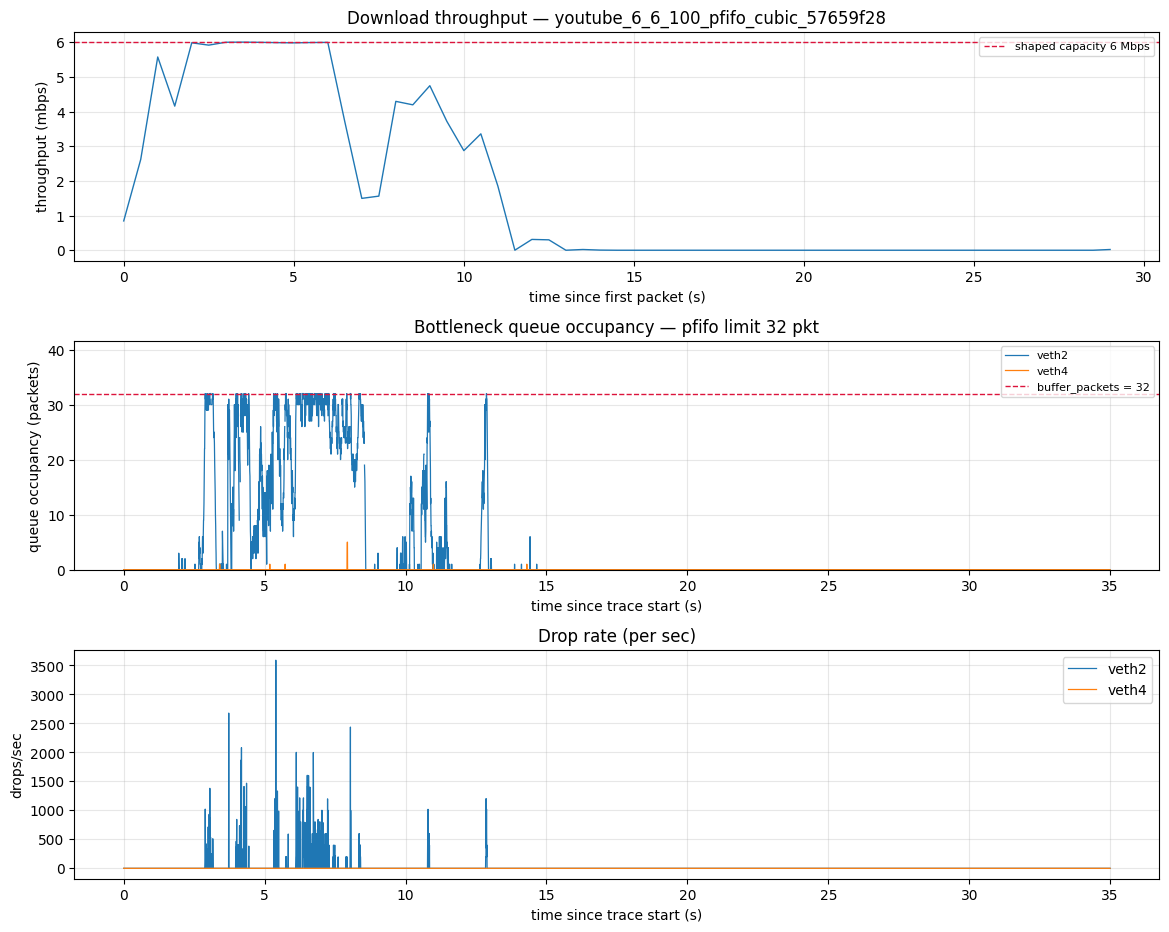

In [5]:
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.35)
ax_thr, ax_queue, ax_drop = (fig.add_subplot(gs[i, 0]) for i in range(3))

if pkts_down is not None and len(pkts_down):
    plot_throughput(pkts_down, bin_seconds=0.5, unit='mbps', ax=ax_thr,
                    title=f'Download throughput — {label}')
    ax_thr.axhline(CAPACITY_MBPS, ls='--', lw=1, color='crimson',
                   label=f'shaped capacity {CAPACITY_MBPS:g} Mbps')
    ax_thr.legend(loc='upper right', fontsize=8)
else:
    ax_thr.set_title('(no pcap)'); ax_thr.axis('off')

if df is not None and not df.empty:
    plot_queue_occupancy(df, unit='packets', ax=ax_queue,
                         title=f'Bottleneck queue occupancy — pfifo limit {BUFFER_PACKETS} pkt')
    ax_queue.axhline(BUFFER_PACKETS, ls='--', lw=1, color='crimson',
                     label=f'buffer_packets = {BUFFER_PACKETS}')
    ax_queue.set_ylim(0, max(BUFFER_PACKETS * 1.3, 5))
    ax_queue.legend(loc='upper right', fontsize=8)
    plot_drop_rate(df, ax=ax_drop, title='Drop rate (per sec)')
else:
    for a in (ax_queue, ax_drop):
        a.set_title('(no queue_trace)'); a.axis('off')

plt.show()

## 4. YouTube player stats (Stats for nerds)

NetGent's `youtube_stats` action polls the player during playback. Every sample it reads the
HTML5 `<video>` element — resolution, buffer health, dropped/total frames, `currentTime` — and
every `nerd_stats_every`-th sample it calls the player's own `getStatsForNerds()` for
codecs/itag, optimal res, and the player's bandwidth estimate.

The four panels below are the ones that matter under a bottleneck:

| Panel | Reads as |
|---|---|
| Resolution | ABR ladder decisions — a drop means the player gave up on the higher rung |
| Buffer health | seconds buffered ahead of the playhead; a downward slope is heading for a stall |
| Dropped frames | decode/render pressure, cumulative |
| Player bandwidth estimate | what the player *thinks* it has, against the shaped capacity |

In [6]:
# YouTube DASH itags -> resolution. 39x are the AV1 ladder, 24x VP9, 13x H.264.
ITAG_RESOLUTION = {
    133: '240p',  134: '360p',  135: '480p',  136: '720p',  137: '1080p',  160: '144p',
    242: '240p',  243: '360p',  244: '480p',  247: '720p',  248: '1080p',  278: '144p',
    271: '1440p', 313: '2160p', 302: '720p60', 303: '1080p60', 308: '1440p60', 315: '2160p60',
    394: '144p',  395: '240p',  396: '360p',  397: '480p',  398: '720p',
    399: '1080p', 400: '1440p', 401: '2160p',
    140: 'audio-128k', 141: 'audio-256k', 251: 'audio-opus',
}

def find_youtube_stats(obj):
    """Find the youtube_stats action output: a dict with a 'samples' series."""
    if isinstance(obj, dict):
        s = obj.get('samples')
        if isinstance(s, list) and s and isinstance(s[0], dict) and 'rel_t' in s[0]:
            return obj
        for v in obj.values():
            hit = find_youtube_stats(v)
            if hit:
                return hit
    elif isinstance(obj, list):
        for v in obj:
            hit = find_youtube_stats(v)
            if hit:
                return hit
    return None

SUMMARY_KEYS = ('resolution', 'optimal_res', 'viewport', 'codecs', 'itag',
                'playback_quality', 'available_quality', 'bandwidth_kbps',
                'buffer_health', 'dropped_frames', 'total_frames', 'video_id')

def summarize_samples(yt):
    """Latest non-null value per key, taken from the series itself.

    getStatsForNerds() is only called every nerd_stats_every-th sample, so the
    final sample usually has no codecs/itag/bandwidth. Scanning backwards per
    key recovers them, and keeps this notebook working against runs produced
    by any version of the action.
    """
    ss = [s for s in yt.get('samples', []) if s.get('collected')]
    out = {}
    for key in SUMMARY_KEYS:
        for sample in reversed(ss):
            if sample.get(key) is not None:
                out[key] = sample[key]
                break
        if key not in out and yt.get(key) is not None:
            out[key] = yt[key]  # fall back to the action's own flattening
    drops = [s['dropped_frames'] for s in ss if isinstance(s.get('dropped_frames'), (int, float))]
    if drops:
        out['dropped_frames_total'] = max(drops)
    res = [s['resolution'] for s in ss if s.get('resolution')]
    if res:
        out['resolutions_seen'] = sorted(set(res))
        out['resolution_switches'] = sum(1 for a, b in zip(res, res[1:]) if a != b)
    return out

yt = find_youtube_stats(result) if result is not None else None

if yt:
    ss   = [s for s in yt['samples'] if s.get('collected')]
    summ = summarize_samples(yt)
    want = meta.get('samples_requested', yt.get('sample_count'))
    span = ss[-1]['rel_t'] if ss else 0
    print(f"player samples : {len(ss)}/{want} requested, spanning {span:.1f}s")
    for k in ('resolution', 'optimal_res', 'viewport', 'codecs', 'itag', 'playback_quality',
              'bandwidth_kbps', 'buffer_health', 'dropped_frames_total', 'total_frames',
              'resolutions_seen', 'resolution_switches'):
        if summ.get(k) is not None:
            extra = f"  ({ITAG_RESOLUTION.get(summ[k], '?')})" if k == 'itag' else ''
            print(f'  {k:22s}: {summ[k]}{extra}')
    if summ.get('available_quality'):
        print(f"  {'available_quality':22s}: {', '.join(summ['available_quality'])}")
    if summ.get('itag') and summ.get('resolution'):
        offered = ITAG_RESOLUTION.get(summ['itag'], '?')
        print(f"\n  delivered rung  : itag {summ['itag']} = {offered}")
        if summ.get('available_quality'):
            best = summ['available_quality'][0]
            print(f"  best on offer   : {best}  "
                  f"({'capped by the link/viewport' if best not in ('auto',) else 'auto'})")
    if yt.get('stopped_early'):
        print(f"\n  !! stopped_early: {yt['stopped_early']}")
        print('     The browser session ended before the watch window did — the stats series')
        print('     is truncated. See the browserless timeout note in cpuc_demo.md.')
else:
    ss, summ = [], {}
    print('No YouTube player stats in this run.')
    print('Collect them with:  python3 cpuc_demo_run.py --watch-seconds 60')
    print('Section 5 derives the equivalent signal from the pcap regardless.')

player samples : 4/4 requested, spanning 3.0s
  resolution            : 854x480
  optimal_res           : 854x480@30 / 854x480@30
  codecs                : av01.0.04M.08 (397) / opus (251)
  itag                  : 397  (480p)
  playback_quality      : large
  bandwidth_kbps        : 805
  buffer_health         : 24.366666
  dropped_frames_total  : 0
  total_frames          : 4
  resolutions_seen      : ['854x480']
  resolution_switches   : 0
  available_quality     : hd2160, hd1440, hd1080, hd720, large, medium, small, tiny, auto

  delivered rung  : itag 397 = 480p
  best on offer   : hd2160  (capped by the link/viewport)

  !! stopped_early: player page went away after 4 sample(s): Page.evaluate: Target page, context or browser has been closed
     The browser session ended before the watch window did — the stats series
     is truncated. See the browserless timeout note in cpuc_demo.md.


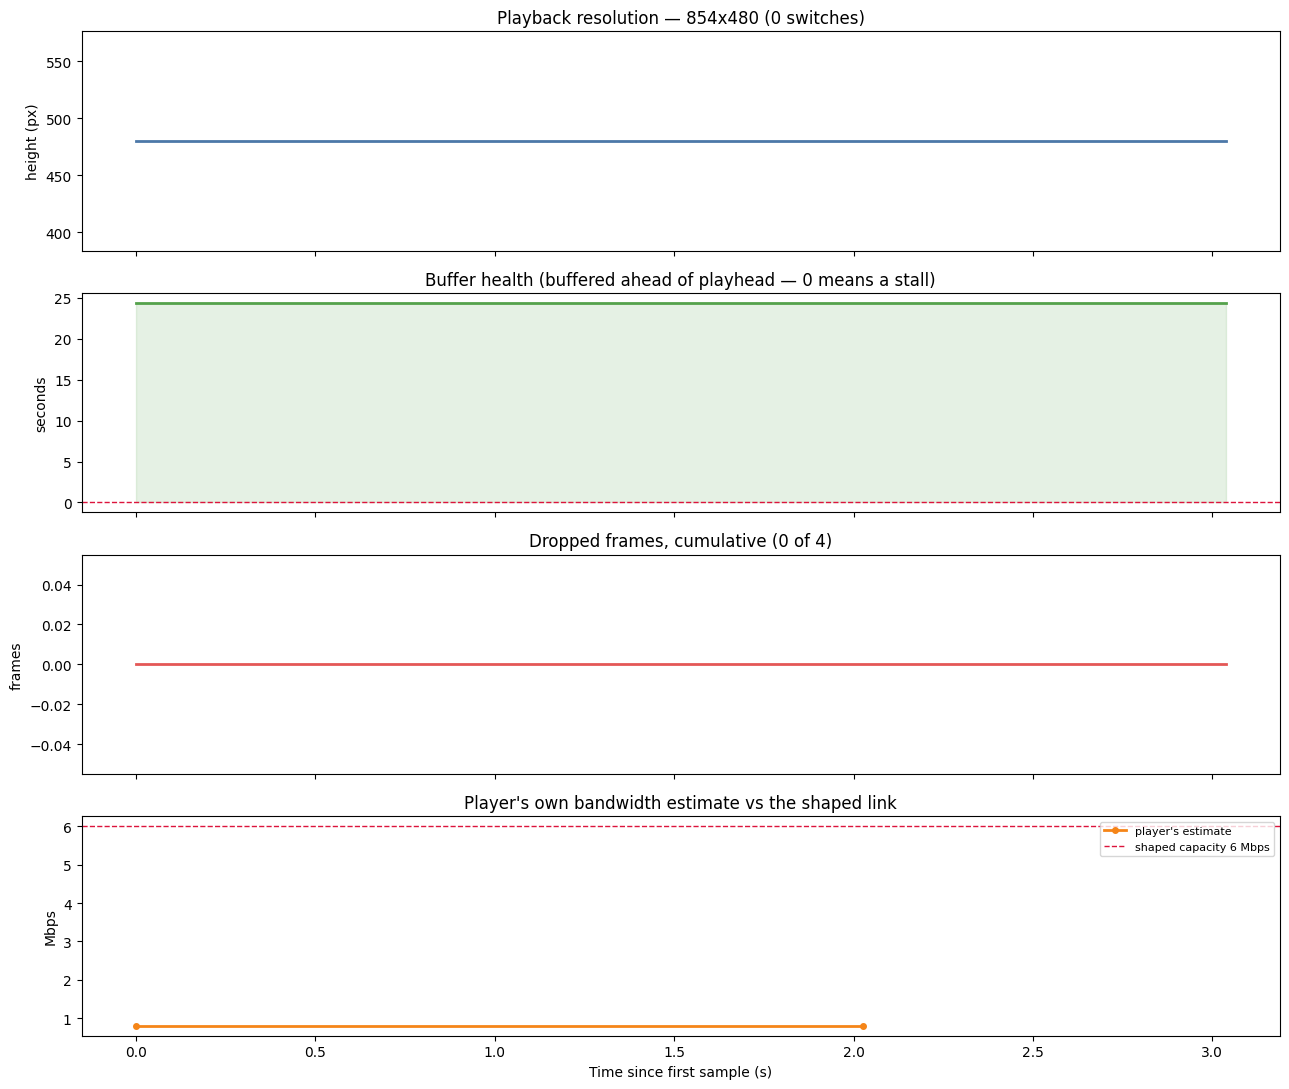

In [7]:
if ss:
    t    = [s['rel_t'] for s in ss]
    hgt  = [s.get('video_height') for s in ss]
    buf  = [s.get('buffer_health') for s in ss]
    drop = [s.get('dropped_frames') for s in ss]
    bw   = [(s['rel_t'], s['bandwidth_kbps']) for s in ss if s.get('bandwidth_kbps')]

    fig, axs = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

    axs[0].step(t, hgt, where='post', color='#4c78a8', lw=2)
    axs[0].set_ylabel('height (px)')
    axs[0].set_title(f"Playback resolution — {summ.get('resolution')} "
                     f"({summ.get('resolution_switches', 0)} switches)")
    if hgt and any(h for h in hgt):
        lo, hi = min(h for h in hgt if h), max(h for h in hgt if h)
        axs[0].set_ylim(lo * 0.8, hi * 1.2)

    axs[1].plot(t, buf, color='#54a24b', lw=2)
    axs[1].fill_between(t, 0, buf, color='#54a24b', alpha=0.15)
    axs[1].axhline(0, ls='--', lw=1, color='crimson')
    axs[1].set_ylabel('seconds')
    axs[1].set_title('Buffer health (buffered ahead of playhead — 0 means a stall)')

    axs[2].plot(t, drop, color='#e45756', lw=2)
    axs[2].set_ylabel('frames')
    axs[2].set_title(f"Dropped frames, cumulative "
                     f"({summ.get('dropped_frames_total', 0)} of {summ.get('total_frames', '?')})")

    if bw:
        axs[3].plot([x for x, _ in bw], [y / 1000 for _, y in bw],
                    marker='o', ms=4, color='#f58518', lw=2, label="player's estimate")
    axs[3].axhline(CAPACITY_MBPS, ls='--', lw=1, color='crimson',
                   label=f'shaped capacity {CAPACITY_MBPS:g} Mbps')
    axs[3].set_ylabel('Mbps'); axs[3].set_xlabel('Time since first sample (s)')
    axs[3].set_title("Player's own bandwidth estimate vs the shaped link")
    axs[3].legend(loc='upper right', fontsize=8)

    plt.tight_layout(); plt.show()
else:
    print('(no player stats series to plot)')

## 5. DASH segment cadence from the pcap

Always available, even with no player stats. YouTube VoD arrives as DASH segments: a burst of
downlink bytes, then an idle gap while the buffer drains. The burst structure is fully visible
under TLS, which gives segment cadence, per-segment bytes, and the delivered video bitrate —
which maps onto a quality tier via the YouTube bitrate ladder.

capture span      : 29.5 s
downlink bytes    : 6.22 MB
avg download rate : 1.69 Mbps  (28% of the 6 Mbps cap)
bursts > 50 kB    : 1
inferred quality  : ~480p (from delivered bitrate)
player reported   : 854x480


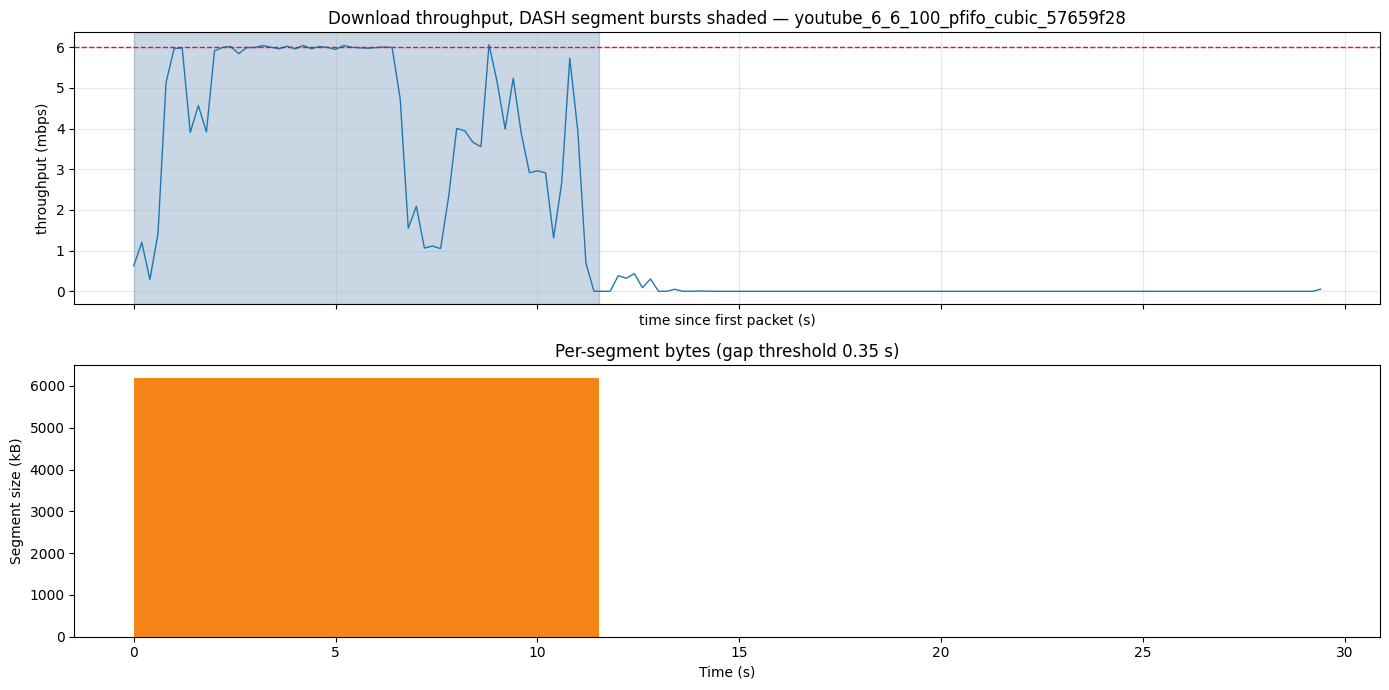

In [8]:
GAP_SECONDS     = float(os.environ.get('GAP_SECONDS', 0.35))
MIN_BURST_BYTES = int(os.environ.get('MIN_BURST_BYTES', 50_000))

# Approximate YouTube VoD bitrate ladder (video-only, mid-range), Mbps.
BITRATE_LADDER = [(0.10, '144p'), (0.30, '240p'), (0.60, '360p'), (1.10, '480p'),
                  (2.50, '720p'), (4.50, '1080p'), (9.00, '1440p'), (16.0, '2160p')]

def infer_tier(mbps):
    tier = 'below 144p'
    for floor, name in BITRATE_LADDER:
        if mbps >= floor:
            tier = name
    return tier

segs = []
if pkts_down is not None and len(pkts_down):
    times = [float(p.time) for p in pkts_down]
    sizes = [len(p) for p in pkts_down]
    t0    = times[0]
    rel   = [t - t0 for t in times]

    bursts = []
    cur = {'start': rel[0], 'end': rel[0], 'bytes': sizes[0]}
    for t, s in zip(rel[1:], sizes[1:]):
        if t - cur['end'] > GAP_SECONDS:
            bursts.append(cur); cur = {'start': t, 'end': t, 'bytes': s}
        else:
            cur['end'] = t; cur['bytes'] += s
    bursts.append(cur)
    segs = [b for b in bursts if b['bytes'] >= MIN_BURST_BYTES]

    span_s   = max(rel[-1] - rel[0], 1e-9)
    avg_mbps = sum(sizes) * 8 / span_s / 1e6
    print(f'capture span      : {span_s:.1f} s')
    print(f'downlink bytes    : {sum(sizes)/1e6:.2f} MB')
    print(f'avg download rate : {avg_mbps:.2f} Mbps  ({avg_mbps/CAPACITY_MBPS*100:.0f}% of the {CAPACITY_MBPS:g} Mbps cap)')
    print(f'bursts > {MIN_BURST_BYTES/1e3:.0f} kB    : {len(segs)}')
    if len(segs) > 1:
        gaps = sorted(segs[i+1]['start'] - segs[i]['end'] for i in range(len(segs)-1))
        durs = sorted(s['end'] - s['start'] for s in segs)
        byts = sorted(s['bytes'] for s in segs)
        print(f'median segment    : {byts[len(byts)//2]/1e3:.0f} kB')
        print(f'median fetch time : {durs[len(durs)//2]:.2f} s')
        print(f'median idle gap   : {gaps[len(gaps)//2]:.2f} s')
    print(f'inferred quality  : ~{infer_tier(avg_mbps)} (from delivered bitrate)')
    if summ.get('resolution'):
        print(f"player reported   : {summ['resolution']}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    for s in segs:
        ax1.axvspan(s['start'], s['end'], color='#4c78a8', alpha=0.30)
    plot_throughput(pkts_down, bin_seconds=0.2, unit='mbps', ax=ax1,
                    title=f'Download throughput, DASH segment bursts shaded — {label}')
    ax1.axhline(CAPACITY_MBPS, ls='--', lw=1, color='crimson')
    ax2.bar([s['start'] for s in segs], [s['bytes']/1e3 for s in segs],
            width=[max(s['end']-s['start'], 0.15) for s in segs], align='edge', color='#f58518')
    ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Segment size (kB)')
    ax2.set_title(f'Per-segment bytes (gap threshold {GAP_SECONDS:g} s)')
    plt.tight_layout(); plt.show()
else:
    print('(no pcap — nothing to derive)')

## 6. Combined view — player state over the bottleneck

The payoff panel: what the player was doing, stacked directly over what the queue was doing, on
one time axis. Buffer health falling while the queue sits at the `pfifo` limit and drops spike
is the signature of a link too small for the chosen representation — the player is about to
step down the ABR ladder or stall.

The two clocks are independent (the pcap starts at the first captured packet, the stats series
at the first successful poll ~5 s later, after page load), so treat the alignment as approximate
unless you set `STATS_T_OFFSET`.

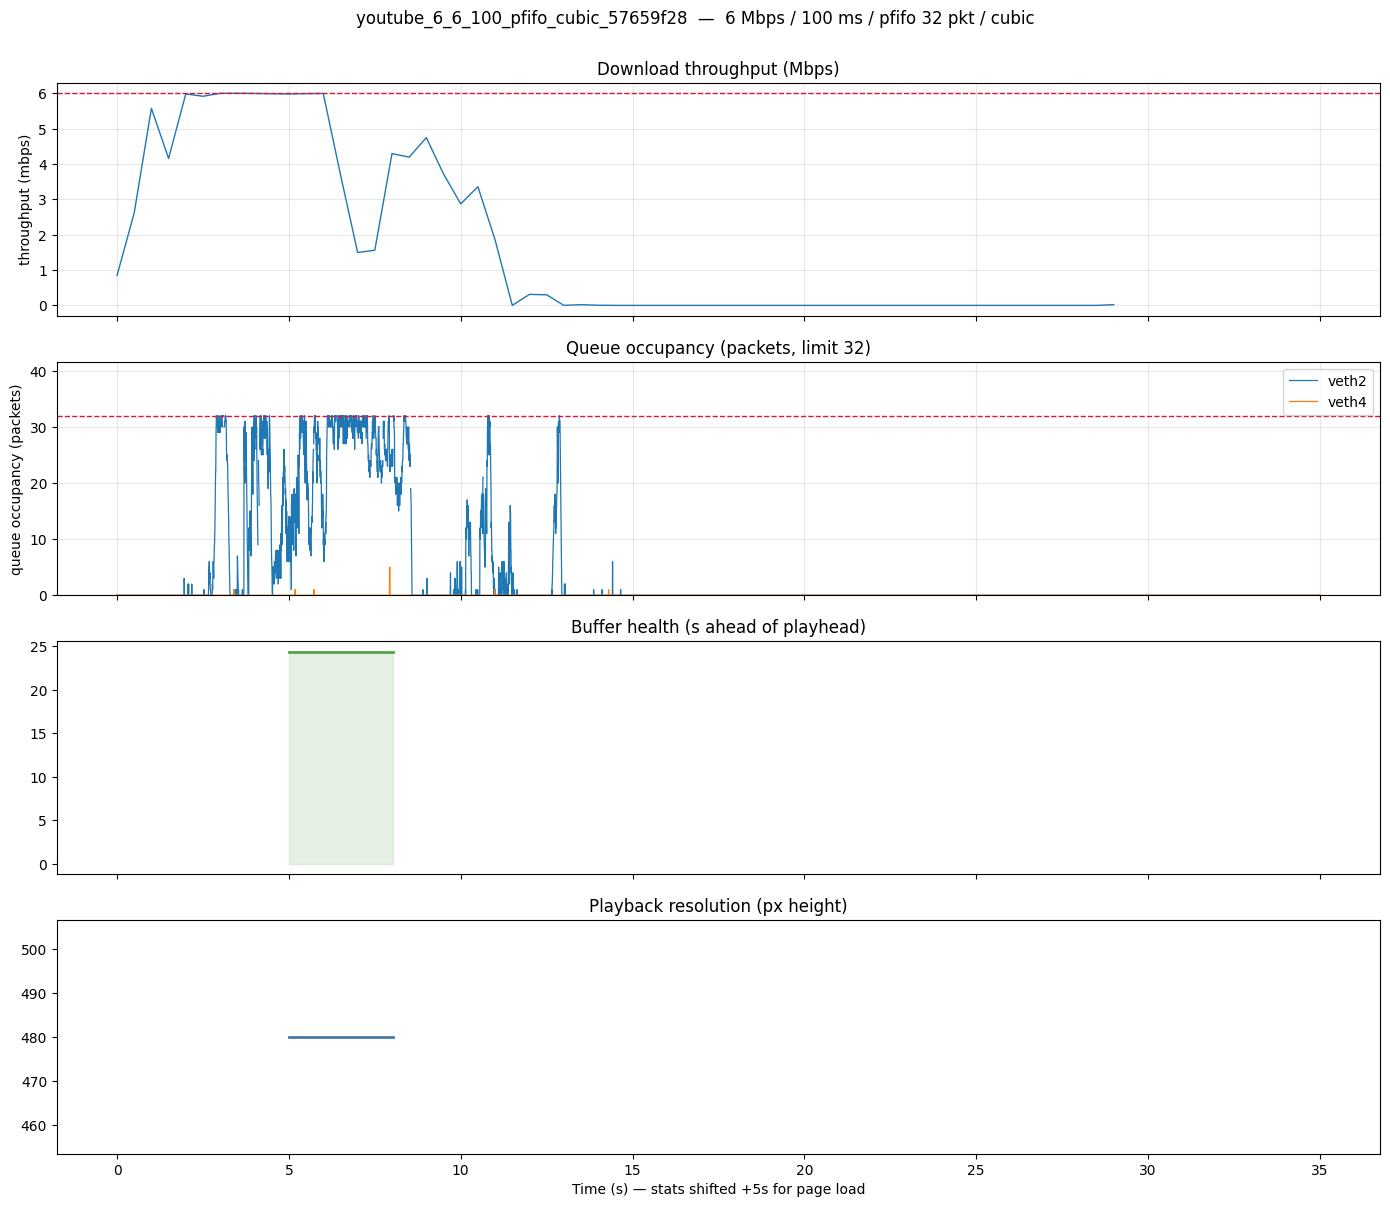

In [9]:
STATS_T_OFFSET = float(os.environ.get('STATS_T_OFFSET', 5.0))  # page-load lead-in

panels = sum([bool(pkts_down is not None and len(pkts_down)),
              bool(df is not None and not df.empty),
              bool(ss), bool(ss)])
if panels:
    fig, axs = plt.subplots(panels, 1, figsize=(14, 3 * panels), sharex=True)
    if panels == 1:
        axs = [axs]
    i = 0

    if pkts_down is not None and len(pkts_down):
        plot_throughput(pkts_down, bin_seconds=0.5, unit='mbps', ax=axs[i], title=None)
        axs[i].axhline(CAPACITY_MBPS, ls='--', lw=1, color='crimson')
        axs[i].set_title('Download throughput (Mbps)'); axs[i].set_xlabel('')
        i += 1

    if df is not None and not df.empty:
        plot_queue_occupancy(df, unit='packets', ax=axs[i], title=None)
        axs[i].axhline(BUFFER_PACKETS, ls='--', lw=1, color='crimson')
        axs[i].set_ylim(0, max(BUFFER_PACKETS * 1.3, 5))
        axs[i].set_title(f'Queue occupancy (packets, limit {BUFFER_PACKETS})'); axs[i].set_xlabel('')
        i += 1

    if ss:
        ts = [s['rel_t'] + STATS_T_OFFSET for s in ss]
        axs[i].plot(ts, [s.get('buffer_health') for s in ss], color='#54a24b', lw=2)
        axs[i].fill_between(ts, 0, [s.get('buffer_health') for s in ss], color='#54a24b', alpha=0.15)
        axs[i].set_title('Buffer health (s ahead of playhead)'); axs[i].set_xlabel('')
        i += 1
        axs[i].step(ts, [s.get('video_height') for s in ss], where='post', color='#4c78a8', lw=2)
        axs[i].set_title('Playback resolution (px height)')

    axs[-1].set_xlabel(f'Time (s) — stats shifted +{STATS_T_OFFSET:g}s for page load')
    fig.suptitle(f'{label}  —  {CAPACITY_MBPS:g} Mbps / {LATENCY_MS:g} ms / '
                 f'pfifo {BUFFER_PACKETS} pkt / {CCA}', y=1.002, fontsize=12)
    plt.tight_layout(); plt.show()
else:
    print('(nothing to plot — no pcap, qtrace, or player stats)')